<a href="https://colab.research.google.com/github/TottiPuc/Machine_learning/blob/master/Anova_Insurance_Decision_Tree_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Anova Insurance — Decision Tree Classification

## Problem Statement

Anova Insurance wants to optimize health-insurance premium pricing using applicants' health information. The goal of this project is to build a **Decision Tree classification model** that predicts whether an applicant is:

- **0 — Healthy**
- **1 — Unhealthy**




In [1]:
# Import libraries
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## Load the Dataset




In [2]:
from google.colab import files
uploaded = files.upload()
data_path = next(iter(uploaded.keys()))

df = pd.read_csv(data_path)

print(f"Dataset loaded from: {data_path}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Saving Healthcare_Dataset_Preprocessed_tree.csv to Healthcare_Dataset_Preprocessed_tree.csv
Dataset loaded from: Healthcare_Dataset_Preprocessed_tree.csv
Shape: 9,549 rows x 23 columns


,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type_Vegan,Diet_Type_Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.000,26.000,111.000,198.000,99.000,72.000,4.000,1.000,5.000,5.000,1,2,2,1,2,1,0,1,False,True,True,False,False
1,8.000,24.000,121.000,199.000,103.000,75.000,2.000,1.000,2.000,9.000,1,0,1,1,2,1,2,2,False,False,True,False,False
2,81.000,27.000,147.000,203.000,100.000,74.000,10.000,-0.000,5.000,1.000,0,2,1,2,0,0,1,0,True,False,False,False,False
3,25.000,21.000,150.000,199.000,102.000,70.000,7.000,3.000,3.000,3.000,0,2,0,1,2,1,2,0,True,False,False,True,False
4,24.000,26.000,146.000,202.000,99.000,76.000,10.000,2.000,5.000,1.000,0,0,1,2,0,2,0,2,False,True,False,True,False


## Initial Data Inspection



In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDescriptive statistics:")
display(df.describe(include="all").T)


Columns:
['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level', 'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake', 'Stress_Level', 'Target', 'Smoking', 'Alcohol', 'Diet', 'MentalHealth', 'PhysicalActivity', 'MedicalHistory', 'Allergies', 'Diet_Type_Vegan', 'Diet_Type_Vegetarian', 'Blood_Group_AB', 'Blood_Group_B', 'Blood_Group_O']

Data types:


,dtype
Age,float64
BMI,float64
Blood_Pressure,float64
Cholesterol,float64
Glucose_Level,float64
Heart_Rate,float64
Sleep_Hours,float64
Exercise_Hours,float64
Water_Intake,float64
Stress_Level,float64



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,"9,549.000",NaN,NaN,NaN,33.807,24.566,0.000,14.000,29.000,50.000,100.000
BMI,"9,549.000",NaN,NaN,NaN,25.661,1.942,19.000,24.000,26.000,27.000,32.000
Blood_Pressure,"9,549.000",NaN,NaN,NaN,130.383,27.878,22.000,113.000,134.000,150.000,225.000
Cholesterol,"9,549.000",NaN,NaN,NaN,199.092,1.969,192.000,198.000,199.000,200.000,207.000
Glucose_Level,"9,549.000",NaN,NaN,NaN,100.226,2.158,93.000,99.000,100.000,102.000,107.000
Heart_Rate,"9,549.000",NaN,NaN,NaN,73.614,1.682,67.000,73.000,74.000,75.000,80.000
Sleep_Hours,"9,549.000",NaN,NaN,NaN,6.951,2.352,0.000,5.000,7.000,9.000,14.000
Exercise_Hours,"9,549.000",NaN,NaN,NaN,1.892,1.379,-0.000,1.000,2.000,3.000,8.000
Water_Intake,"9,549.000",NaN,NaN,NaN,3.581,1.623,-0.000,2.000,4.000,5.000,10.000
Stress_Level,"9,549.000",NaN,NaN,NaN,4.382,2.079,0.000,3.000,4.000,6.000,12.000


In [4]:
quality_report = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2),
    "Unique Values": df.nunique()
}).sort_values("Missing Values", ascending=False)

print(f"Duplicate rows: {df.duplicated().sum():,}")
display(quality_report)


Duplicate rows: 0


,Missing Values,Missing %,Unique Values
Age,0,0.000,101
BMI,0,0.000,14
Blood_Pressure,0,0.000,175
Cholesterol,0,0.000,16
Glucose_Level,0,0.000,15
Heart_Rate,0,0.000,14
Sleep_Hours,0,0.000,15
Exercise_Hours,0,0.000,9
Water_Intake,0,0.000,11
Stress_Level,0,0.000,13


,Count,Percentage
Healthy (0),4570,47.860
Unhealthy (1),4979,52.140


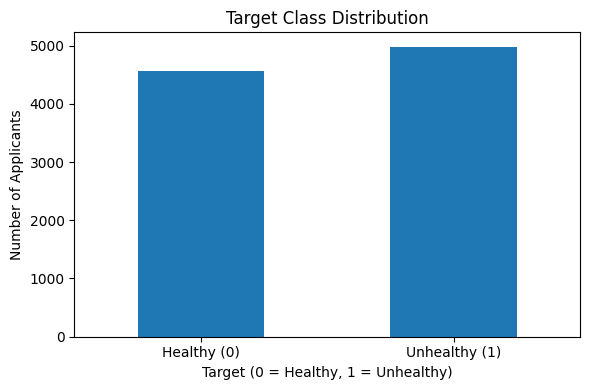

In [5]:
target_counts = df["Target"].value_counts().sort_index()
target_percent = (df["Target"].value_counts(normalize=True).sort_index() * 100).round(2)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent
})
target_summary.index = ["Healthy (0)" if i == 0 else "Unhealthy (1)" for i in target_summary.index]

display(target_summary)

ax = target_counts.plot(kind="bar", figsize=(6, 4))
ax.set_title("Target Class Distribution")
ax.set_xlabel("Target (0 = Healthy, 1 = Unhealthy)")
ax.set_ylabel("Number of Applicants")
ax.set_xticklabels(["Healthy (0)", "Unhealthy (1)"], rotation=0)
plt.tight_layout()
plt.show()


## Data Cleaning and Validation



In [6]:
data = df.copy()

# Remove duplicate rows if present
data = data.drop_duplicates().reset_index(drop=True)

# Validate target
invalid_target = ~data["Target"].isin([0, 1])
if invalid_target.any():
    print(f"Removing {invalid_target.sum()} rows with invalid Target values.")
    data = data.loc[~invalid_target].copy()

# Negative age values are considered invalid
if "Age" in data.columns:
    negative_age_count = (data["Age"] < 0).sum()
    print(f"Negative Age values found: {negative_age_count}")
    data.loc[data["Age"] < 0, "Age"] = np.nan

# Convert infinities to missing values
data = data.replace([np.inf, -np.inf], np.nan)

# Convert boolean columns to integer
bool_cols = data.select_dtypes(include="bool").columns
data[bool_cols] = data[bool_cols].astype(int)

# Impute numerical predictor missing values with the median
predictor_cols = [c for c in data.columns if c != "Target"]
numeric_predictors = data[predictor_cols].select_dtypes(include=np.number).columns

for col in numeric_predictors:
    if data[col].isna().any():
        data[col] = data[col].fillna(data[col].median())

# If category columns are present impute them with mode
categorical_predictors = data[predictor_cols].select_dtypes(include=["object", "category"]).columns

for col in categorical_predictors:
    if data[col].isna().any():
        data[col] = data[col].fillna(data[col].mode().iloc[0])

print(f"Clean dataset shape: {data.shape}")
print(f"Remaining missing values: {data.isna().sum().sum()}")
print(f"Remaining duplicate rows: {data.duplicated().sum()}")


Negative Age values found: 0
Clean dataset shape: (9549, 23)
Remaining missing values: 0
Remaining duplicate rows: 0


## Exploratory Data Analysis (EDA)




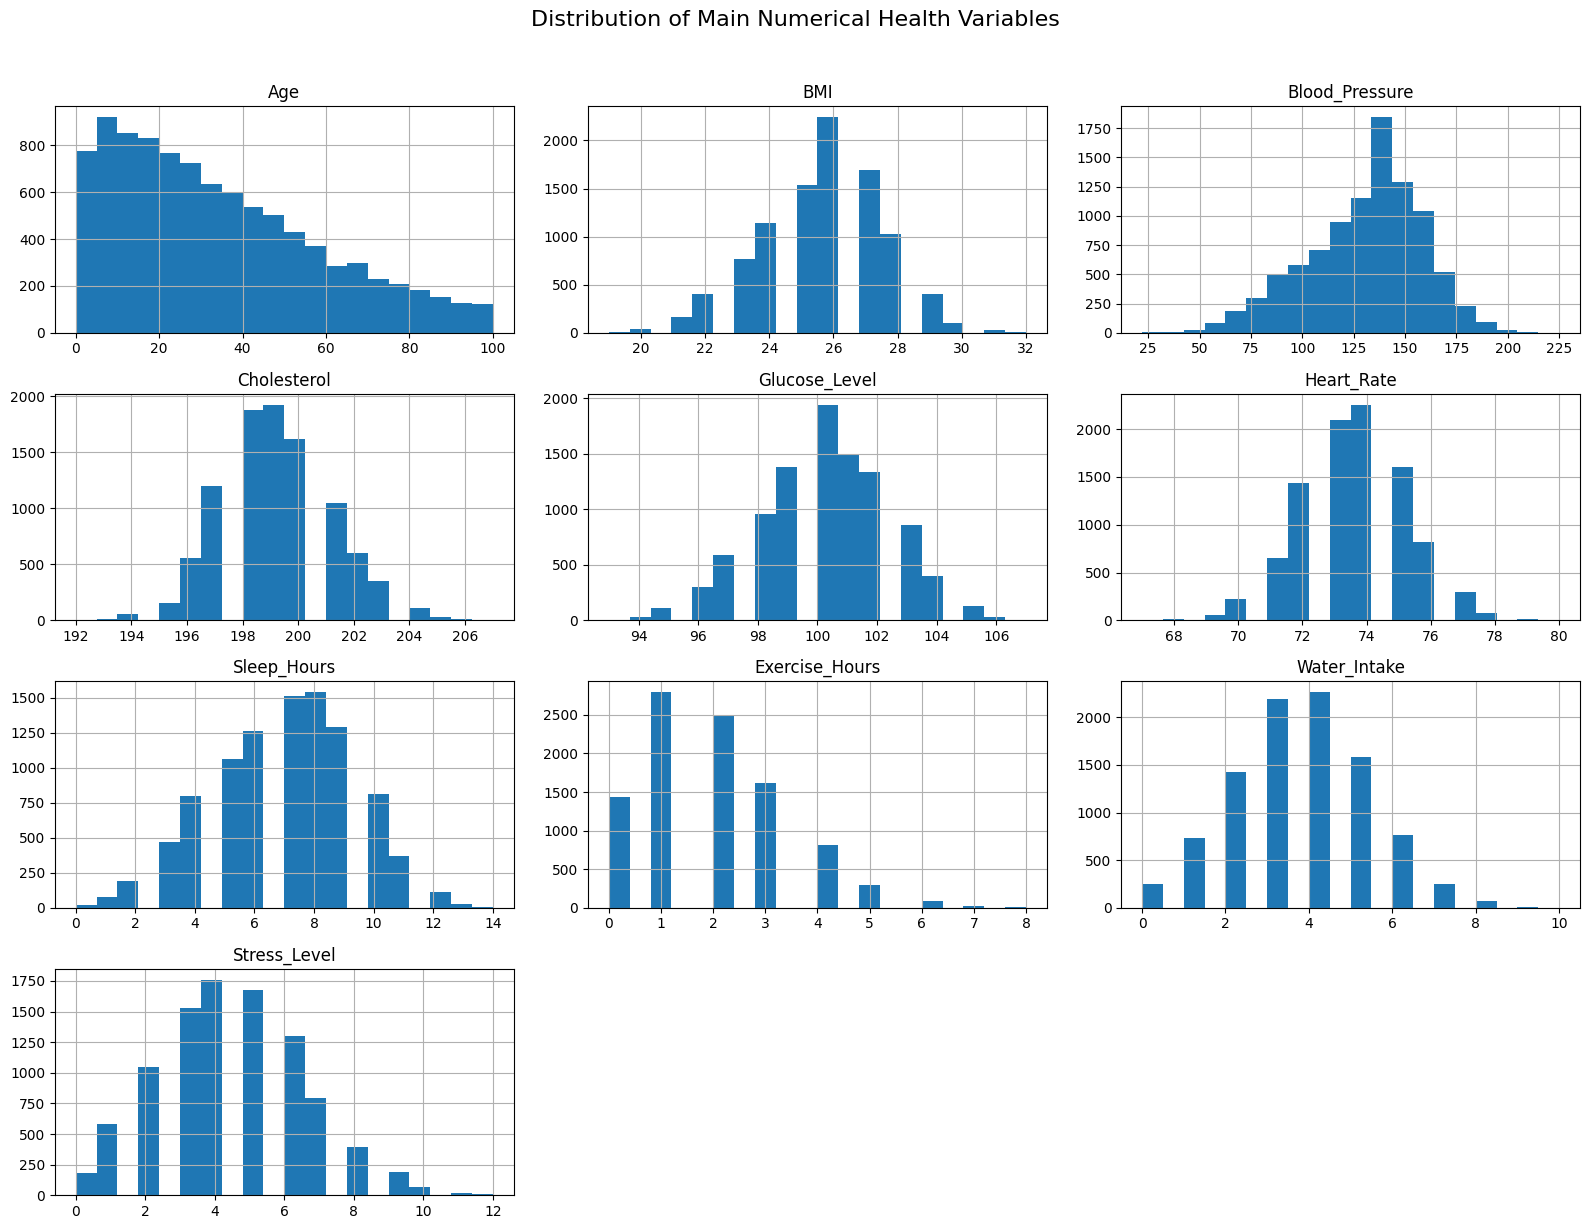

In [7]:
continuous_features = [
    "Age", "BMI", "Blood_Pressure", "Cholesterol", "Glucose_Level",
    "Heart_Rate", "Sleep_Hours", "Exercise_Hours", "Water_Intake", "Stress_Level"
]
continuous_features = [c for c in continuous_features if c in data.columns]

data[continuous_features].hist(figsize=(16, 12), bins=20)
plt.suptitle("Distribution of Main Numerical Health Variables", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


In [8]:
group_summary = data.groupby("Target")[continuous_features].mean().T
group_summary.columns = ["Healthy (0)", "Unhealthy (1)"]
group_summary["Difference (1 - 0)"] = group_summary["Unhealthy (1)"] - group_summary["Healthy (0)"]
display(group_summary.sort_values("Difference (1 - 0)", key=abs, ascending=False))


,Healthy (0),Unhealthy (1),Difference (1 - 0)
Blood_Pressure,141.448,120.226,-21.222
Age,38.698,29.318,-9.380
BMI,24.821,26.431,1.610
Cholesterol,199.758,198.480,-1.279
Stress_Level,4.123,4.620,0.497
Glucose_Level,100.388,100.077,-0.312
Heart_Rate,73.730,73.508,-0.222
Water_Intake,3.646,3.521,-0.125
Sleep_Hours,6.888,7.010,0.122
Exercise_Hours,1.881,1.903,0.023


Correlation with the Target




,Correlation with Target
BMI,0.414
Blood_Pressure,-0.380
Cholesterol,-0.324
Age,-0.191
Stress_Level,0.119
Glucose_Level,-0.072
Heart_Rate,-0.066
Water_Intake,-0.038
Sleep_Hours,0.026
Diet_Type_Vegan,0.024


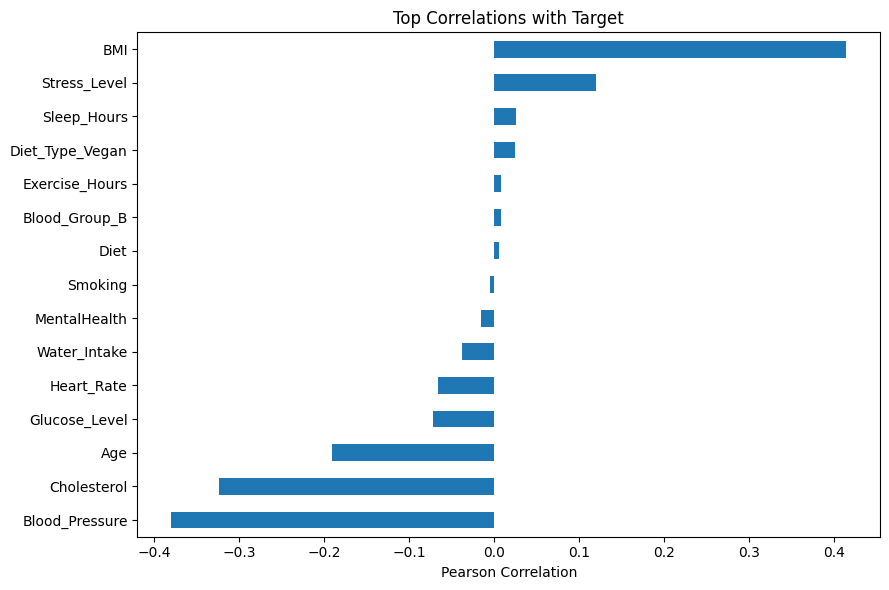

In [9]:
numeric_data = data.select_dtypes(include=np.number)

target_corr = (
    numeric_data.corr()["Target"]
    .drop("Target")
    .sort_values(key=abs, ascending=False)
)

display(target_corr.to_frame("Correlation with Target"))

ax = target_corr.head(15).sort_values().plot(kind="barh", figsize=(9, 6))
ax.set_title("Top Correlations with Target")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()


In [10]:
X = data.drop(columns="Target").copy()
y = data["Target"].astype(int).copy()


categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

if categorical_cols:
    print("Encoding categorical columns:", categorical_cols)
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)


bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
display(X.head())


Feature matrix shape: (9549, 22)
Target shape: (9549,)


,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type_Vegan,Diet_Type_Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.000,26.000,111.000,198.000,99.000,72.000,4.000,1.000,5.000,5.000,2,2,1,2,1,0,1,0,1,1,0,0
1,8.000,24.000,121.000,199.000,103.000,75.000,2.000,1.000,2.000,9.000,0,1,1,2,1,2,2,0,0,1,0,0
2,81.000,27.000,147.000,203.000,100.000,74.000,10.000,-0.000,5.000,1.000,2,1,2,0,0,1,0,1,0,0,0,0
3,25.000,21.000,150.000,199.000,102.000,70.000,7.000,3.000,3.000,3.000,2,0,1,2,1,2,0,1,0,0,1,0
4,24.000,26.000,146.000,202.000,99.000,76.000,10.000,2.000,5.000,1.000,0,1,2,0,2,0,2,0,1,0,1,0


## Train/Test Split




In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"Training unhealthy rate: {y_train.mean():.3%}")
print(f"Test unhealthy rate:     {y_test.mean():.3%}")


Training set: 7,639 rows
Test set:     1,910 rows
Training unhealthy rate: 52.140%
Test unhealthy rate:     52.147%


## Baseline Decision Tree




In [12]:
baseline_tree = DecisionTreeClassifier(random_state=42)
baseline_tree.fit(X_train, y_train)

baseline_train_pred = baseline_tree.predict(X_train)
baseline_test_pred = baseline_tree.predict(X_test)
baseline_test_prob = baseline_tree.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "Train Accuracy": accuracy_score(y_train, baseline_train_pred),
    "Test Accuracy": accuracy_score(y_test, baseline_test_pred),
    "Precision": precision_score(y_test, baseline_test_pred),
    "Recall": recall_score(y_test, baseline_test_pred),
    "F1 Score": f1_score(y_test, baseline_test_pred),
    "ROC-AUC": roc_auc_score(y_test, baseline_test_prob)
}

display(pd.DataFrame(baseline_metrics, index=["Baseline Decision Tree"]).T)

print("\nClassification Report — Baseline Decision Tree")
print(classification_report(
    y_test,
    baseline_test_pred,
    target_names=["Healthy", "Unhealthy"]
))


,Baseline Decision Tree
Train Accuracy,1.000
Test Accuracy,0.892
Precision,0.884
Recall,0.912
F1 Score,0.898
ROC-AUC,0.891



Classification Report — Baseline Decision Tree
              precision    recall  f1-score   support

     Healthy       0.90      0.87      0.88       914
   Unhealthy       0.88      0.91      0.90       996

    accuracy                           0.89      1910
   macro avg       0.89      0.89      0.89      1910
weighted avg       0.89      0.89      0.89      1910



## Decision Tree Hyperparameter Tuning




In [13]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 8, 10, 12, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print(f"Best cross-validation F1: {grid_search.best_score_:.4f}")


Best parameters:
{'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best cross-validation F1: 0.9028


## Final Decision Tree Evaluation


In [14]:
best_tree = grid_search.best_estimator_

final_train_pred = best_tree.predict(X_train)
final_test_pred = best_tree.predict(X_test)
final_test_prob = best_tree.predict_proba(X_test)[:, 1]

final_metrics = {
    "Train Accuracy": accuracy_score(y_train, final_train_pred),
    "Test Accuracy": accuracy_score(y_test, final_test_pred),
    "Precision": precision_score(y_test, final_test_pred),
    "Recall": recall_score(y_test, final_test_pred),
    "F1 Score": f1_score(y_test, final_test_pred),
    "ROC-AUC": roc_auc_score(y_test, final_test_prob)
}

comparison = pd.DataFrame({
    "Baseline Decision Tree": baseline_metrics,
    "Tuned Decision Tree": final_metrics
})

display(comparison)

print("\nClassification Report — Tuned Decision Tree")
print(classification_report(
    y_test,
    final_test_pred,
    target_names=["Healthy", "Unhealthy"]
))


,Baseline Decision Tree,Tuned Decision Tree
Train Accuracy,1.000,0.943
Test Accuracy,0.892,0.899
Precision,0.884,0.895
Recall,0.912,0.915
F1 Score,0.898,0.905
ROC-AUC,0.891,0.943



Classification Report — Tuned Decision Tree
              precision    recall  f1-score   support

     Healthy       0.90      0.88      0.89       914
   Unhealthy       0.89      0.91      0.90       996

    accuracy                           0.90      1910
   macro avg       0.90      0.90      0.90      1910
weighted avg       0.90      0.90      0.90      1910



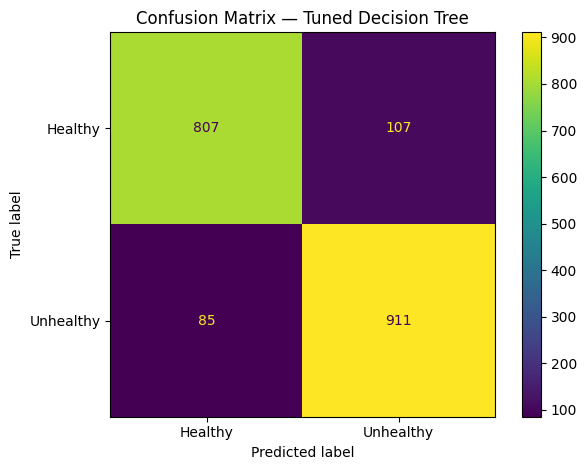

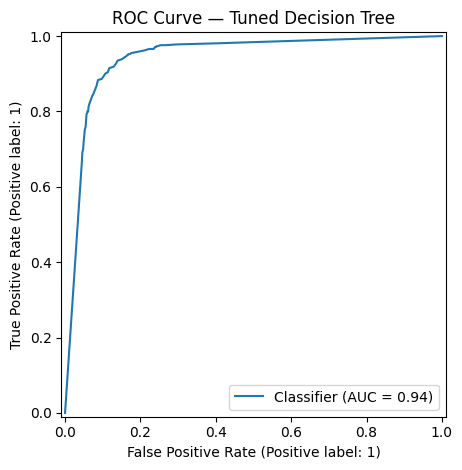

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_test_pred,
    display_labels=["Healthy", "Unhealthy"],
    cmap=None
)
plt.title("Confusion Matrix — Tuned Decision Tree")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, final_test_prob)
plt.title("ROC Curve — Tuned Decision Tree")
plt.tight_layout()
plt.show()


## Visualize the Decision Tree




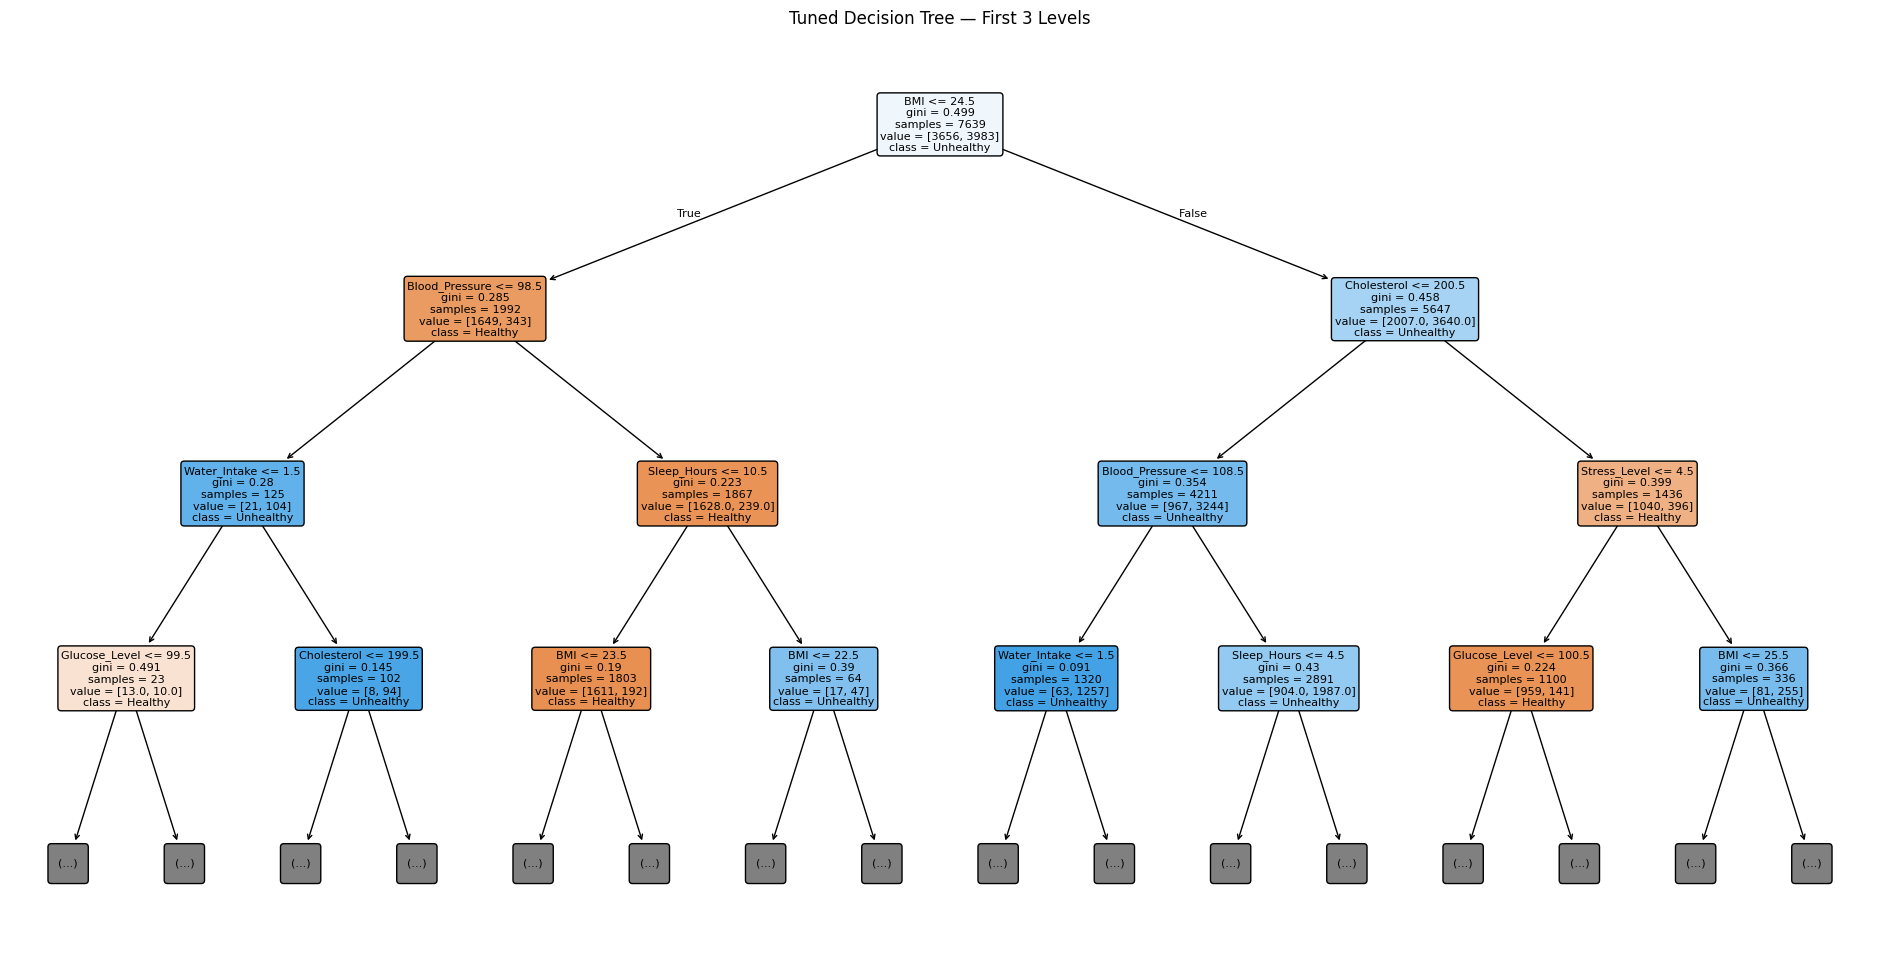

In [15]:
plt.figure(figsize=(24, 12))
plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=["Healthy", "Unhealthy"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Tuned Decision Tree — First 3 Levels")
plt.show()
